In [ ]:
"""
Predicting USD/GBP exchange rates using LSTM neural networks.
The previous experiments had very good train val_loss but poor train loss.

Hypothesis : shuffling before train test split and the fact that each sequence contains 
data from previous sequence means that validation data has mostly already been seen by the model.

Solution : Split before shuffling and batching, to ensure that validation data is unseen.
"""

In [32]:
from datetime import datetime, timedelta
import os
import pandas as pd
import glob

EXPERIMENT_NAME = "usdgbp_forecast_005"

# makedir for experiment
os.makedirs(EXPERIMENT_NAME, exist_ok=True)

DATA_DIR = "data"

# Load all CSV files from data directory
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(csv_files)} CSV files: {csv_files}")

dfs = []
for csv_file in csv_files:
    # Read header from row 0, skip rows 1 and 2 (ticker info and 'Datetime' label)
    df_temp = pd.read_csv(csv_file, header=0, skiprows=[1, 2], parse_dates=[0], index_col=0)
    df_temp.index.name = "Datetime"
    print(f"Loaded {csv_file}: {len(df_temp)} rows")
    dfs.append(df_temp)

# Combine all dataframes
df = pd.concat(dfs)

# Remove timezone info if present
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

# Remove duplicate rows by datetime index
df = df[~df.index.duplicated(keep='first')]

# Sort by datetime
df = df.sort_index()

print(f"\nTotal rows after deduplication: {len(df)}")

# prove that there are no duplicate indices
assert not df.index.duplicated().any(), "There are still duplicate datetime indices!"

# TODO check values will always be between 0 and 1
for column in df.columns:
    print(f"{column} max: {df[column].max()}")
    print(f"{column} min: {df[column].min()}")

# Days when the markets are closed are not included in the dataset by default !
print(df.iloc[2735:2740])


Found 4 CSV files: ['data/GBPUSD=X_1m_2025-12-22_to_2025-12-30.csv', 'data/EURUSD=X_1m_2025-12-23_to_2025-12-31.csv', 'data/EURUSD=X_1m_2025-12-22_to_2025-12-30.csv', 'data/GBPUSD=X_1m_2025-12-23_to_2025-12-31.csv']
Loaded data/GBPUSD=X_1m_2025-12-22_to_2025-12-30.csv: 8642 rows
Loaded data/EURUSD=X_1m_2025-12-23_to_2025-12-31.csv: 8239 rows
Loaded data/EURUSD=X_1m_2025-12-22_to_2025-12-30.csv: 8627 rows
Loaded data/GBPUSD=X_1m_2025-12-23_to_2025-12-31.csv: 8254 rows

Total rows after deduplication: 9685
Close max: 1.3534914255142212
Close min: 1.172333002090454
High max: 1.3534914255142212
High min: 1.172333002090454
Low max: 1.3534914255142212
Low min: 1.172333002090454
Open max: 1.3534914255142212
Open min: 1.172333002090454
Volume max: 0
Volume min: 0
                        Close      High       Low      Open  Volume
Datetime                                                           
2025-12-23 22:01:00  1.349619  1.349619  1.349619  1.349619       0
2025-12-23 22:02:00  1.349619 

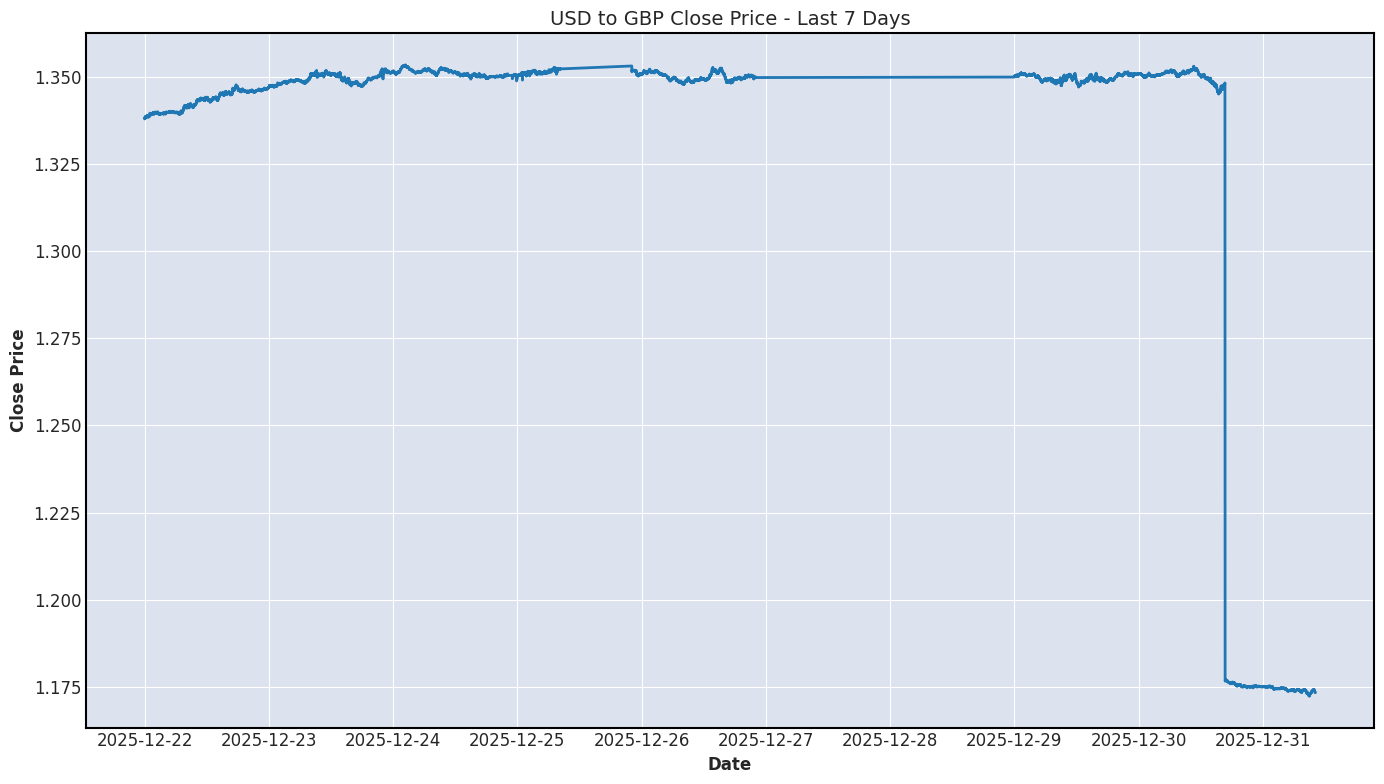

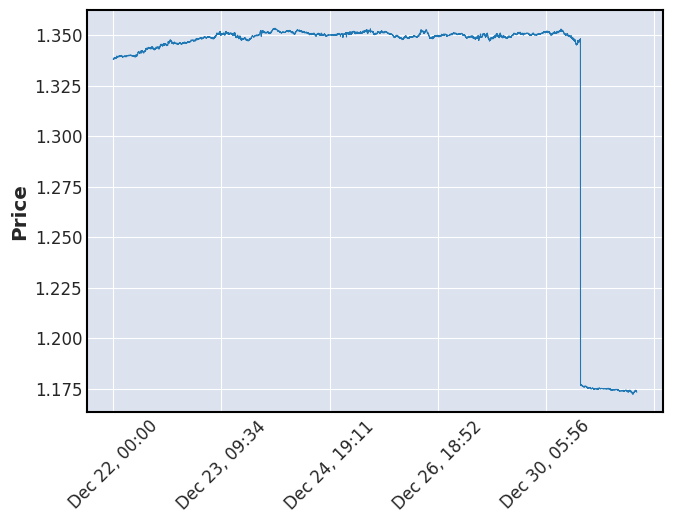

In [33]:
# use matplot to plot close price
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.plot(df.index, df['Close'], linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.title('USD to GBP Close Price - Last 7 Days', fontsize=14)
plt.tight_layout()
plt.show()

# plot full week candlestick chart
import mplfinance as mpf

df_plot = df.copy()

df_plot.index.name = 'Date'

mpf.plot(df_plot, type='line')


In [34]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib

# Parameters
SEQUENCE_LENGTH = 30
FORECAST_LENGTH = 5

# Remove any NaN values
df_clean = df.dropna()

# keep only training columns
df_clean = df_clean.reset_index()

# Hour of day (0-23)
# df_clean["Hour_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.hour / 24)
# df_clean["Hour_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.hour / 24)

# # Minute of hour (0-59)
# df_clean["Minute_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.minute / 60)
# df_clean["Minute_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.minute / 60)

# # Day of week (0-6)
# df_clean["DayOfWeek_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.dayofweek / 7)
# df_clean["DayOfWeek_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.dayofweek / 7)

df_clean = df_clean[
    [
        "Datetime",
        "Open",
        "High",
        "Low",
        "Close",
        # "Hour_sin",
        # "Hour_cos",
        # "Minute_sin",
        # "Minute_cos",
        # "DayOfWeek_sin",
        # "DayOfWeek_cos",
    ]
]  # TODO test with time cos sin features

# Scale the features
feature_cols = ["Open", "High", "Low", "Close"]
scaler = MinMaxScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

# Save scaler for later inverse transformation
joblib.dump(scaler, os.path.join(EXPERIMENT_NAME, "scaler.pkl"))

# Close is the last column (index 3), needed for inverse transform
CLOSE_COL_IDX = feature_cols.index("Close")
print(f"Close column index: {CLOSE_COL_IDX}")

# Create sequences
X = []
y = []
time_delta_issues = 0

for i in range(len(df_clean) - SEQUENCE_LENGTH - FORECAST_LENGTH + 1):
    # Remove sequences with large time deltas
    if (
        df_clean.iloc[i : i + SEQUENCE_LENGTH + FORECAST_LENGTH]["Datetime"].diff()
        > timedelta(minutes=10)
    ).any():
        time_delta_issues += 1
        continue

    # Get 30 minutes of data as input
    x_seq = df_clean.iloc[i : i + SEQUENCE_LENGTH].drop(['Datetime'], axis=1).values
    
    # Get next 5 minutes as output
    y_seq = df_clean.iloc[i + SEQUENCE_LENGTH : i + SEQUENCE_LENGTH + FORECAST_LENGTH][
        "Close"
    ].values

    X.append(x_seq)
    y.append(y_seq)
print(f"Number of sequences with time delta issues: {time_delta_issues}")
X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of samples: {len(X)}")

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((X, y))

train, test = tf.keras.utils.split_dataset(
    dataset, left_size=0.8, shuffle=False, seed=42
)

train = train.shuffle(buffer_size=1000).batch(32)
test = test.shuffle(buffer_size=1000).batch(32)

print(f"\nTraining set batches: {len(train)}")
print(f"Testing set batches: {len(test)}")


input_features = len(X[0][0])
print(f"Input features: {input_features}")

Close column index: 3
Number of sequences with time delta issues: 102
X shape: (9549, 30, 4)
y shape: (9549, 5)
Number of samples: 9549

Training set batches: 239
Testing set batches: 60
Input features: 4


In [ ]:
# Bayesian Optimization of LSTM Hyperparameters
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

OUTPUT_FEATURES = 1  # Predict only the 'Close' price


def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(SEQUENCE_LENGTH, input_features)))
    model.add(
        tf.keras.layers.LSTM(
            units=hp.Int("units", min_value=32, max_value=256, step=32),
            return_sequences=False,
        )
    )
    model.add(
        tf.keras.layers.Dropout(
            hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1)
        )
    )
    model.add(
        tf.keras.layers.Dense(
            FORECAST_LENGTH * OUTPUT_FEATURES,  # Output: (batch, 5)
        )
    )
    # No Reshape needed - output is (batch, 5) matching target y shape
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float("learning_rate", 1e-4, 1e-2)),
        loss="mse",
    )
    return model


tuner = kt.BayesianOptimization(
    build_model,
    objective="val_loss",
    max_trials=30,
    directory=f"{EXPERIMENT_NAME}/lstm_tuning",
    project_name="usd_gbp_forecasting",
)

tuner.search(
    train.take(len(train) // 3),
    epochs=30,
    validation_data=test.take(len(test) // 3),
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            start_from_epoch=5,
        )
    ],
)

print(tuner.results_summary())

# get best parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# create model with best hyperparameters
model = tuner.hypermodel.build(best_hps)

Trial 19 Complete [00h 02m 10s]
val_loss: 0.007169117219746113

Best val_loss So Far: 0.004861007444560528
Total elapsed time: 00h 21m 47s

Search: Running Trial #20

Value             |Best Value So Far |Hyperparameter
256               |64                |units
0.1               |0.2               |dropout
0.0021379         |0.0022767         |learning_rate

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0495 - val_loss: 0.0153
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0032 - val_loss: 0.0114
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0025 - val_loss: 0.0089
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0020 - val_loss: 0.0100
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0018 - val_loss: 0.0078
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0017 - val_loss: 0.0074
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0016 - val_loss: 0.0074
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s

In [ ]:
model.fit(
    train,
    epochs=100,
    validation_data=test,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            start_from_epoch=5,
        )
    ],
)

model.save(os.path.join(EXPERIMENT_NAME, "usdgbp_lstm_model.keras"))

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0111 - val_loss: 2.2033e-04
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0025 - val_loss: 3.1488e-04
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0019 - val_loss: 2.7222e-04
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0017 - val_loss: 3.5746e-04
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0014 - val_loss: 2.1457e-04
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0013 - val_loss: 4.8769e-04
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0012 - val_loss: 2.8323e-04
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0012 - val_loss: 2.3672e-04
Epoch 9/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0011 - val_loss: 2.7288e-04
Epoch 10/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0010 - val_loss: 6.6055e-04
Epoch 11/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 9.1937e-04 - va

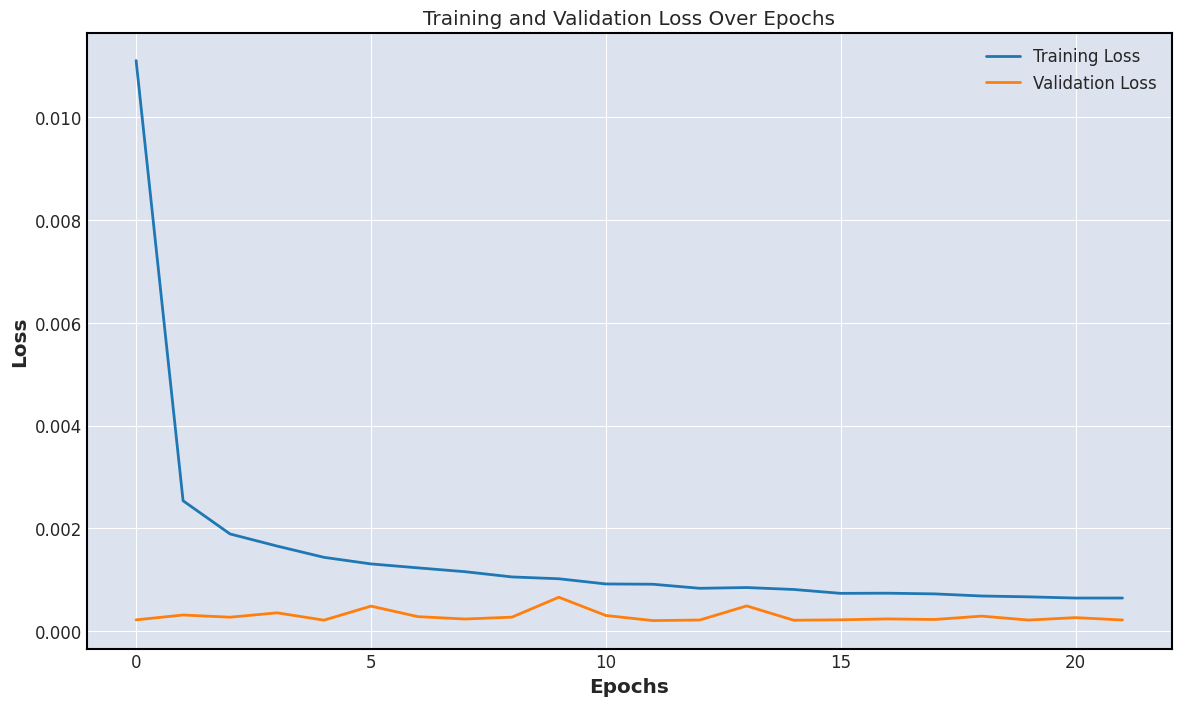

In [ ]:
# plot training history
history = model.history.history
plt.figure(figsize=(14, 8))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.savefig(os.path.join(EXPERIMENT_NAME, "training_validation_loss.png"))
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


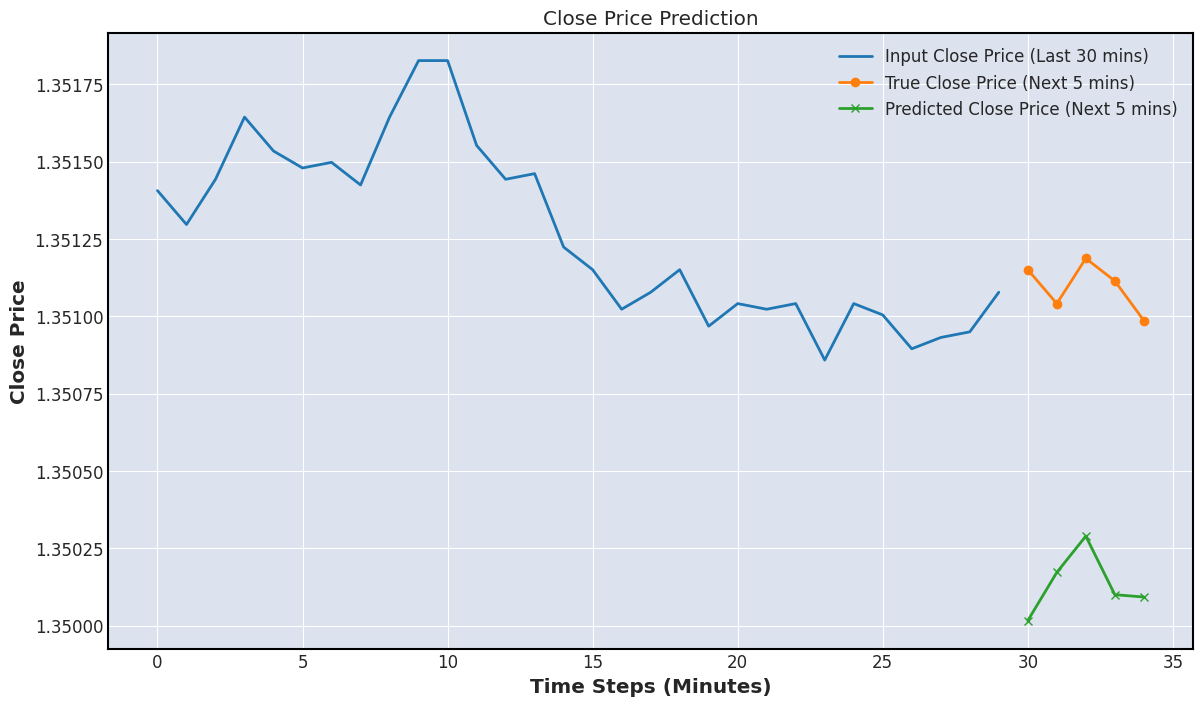

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


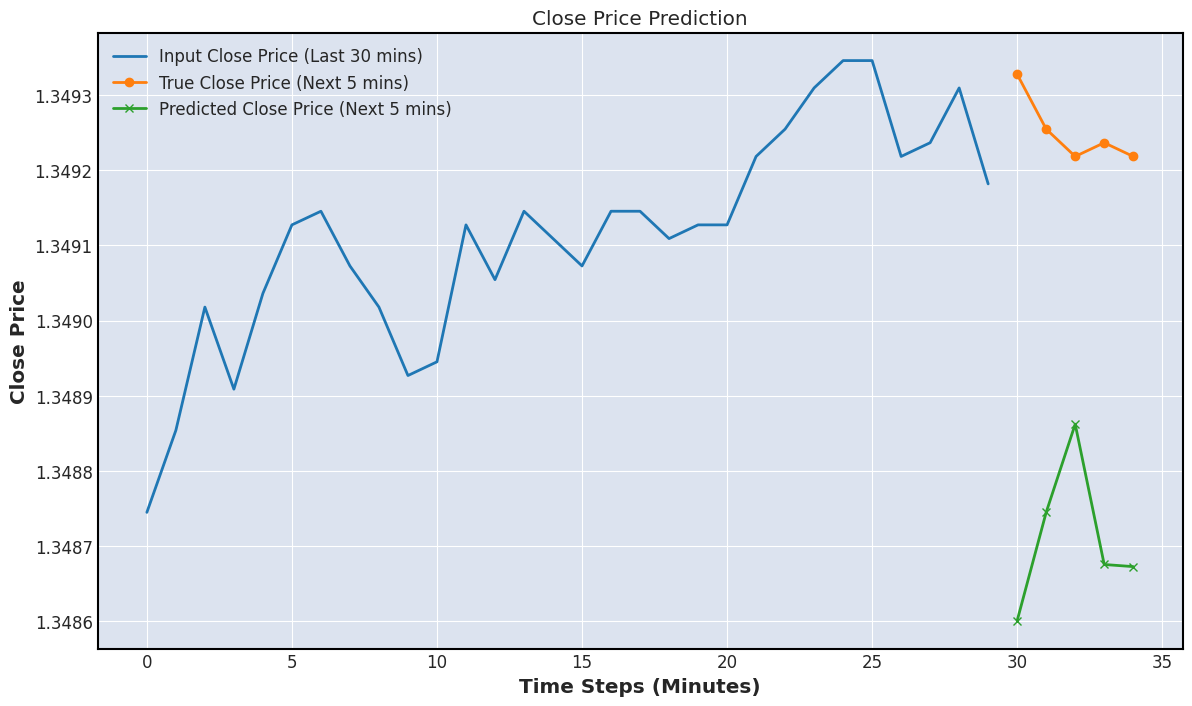

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


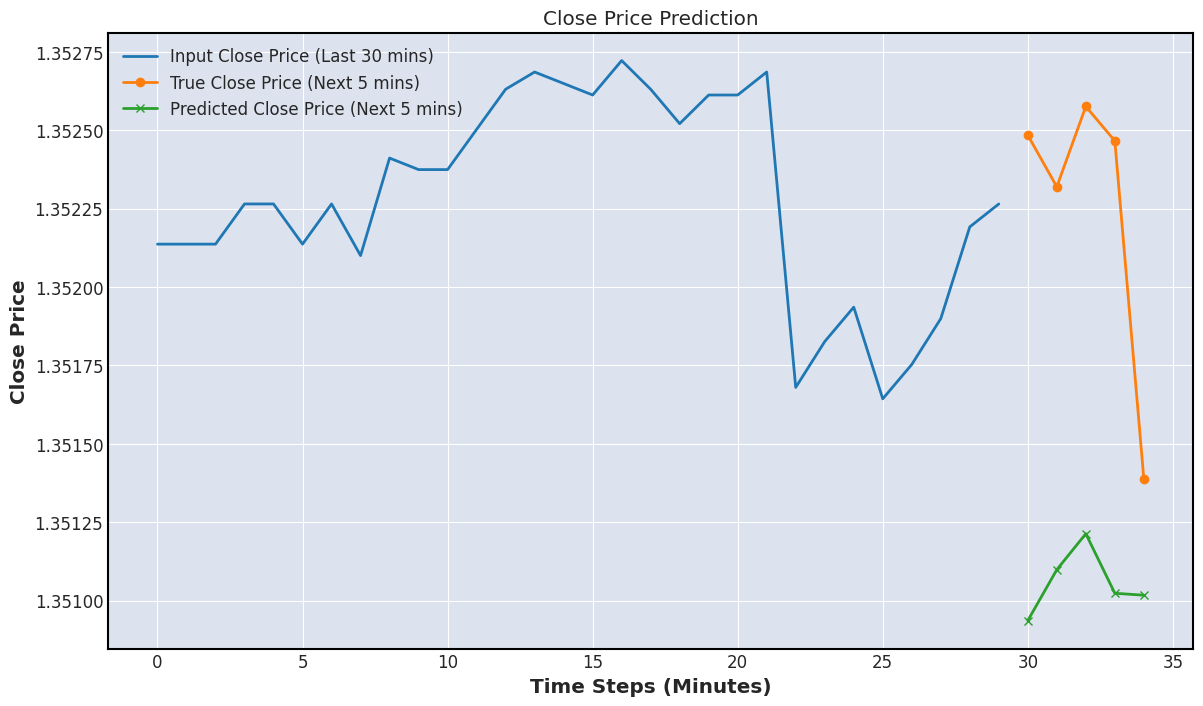

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


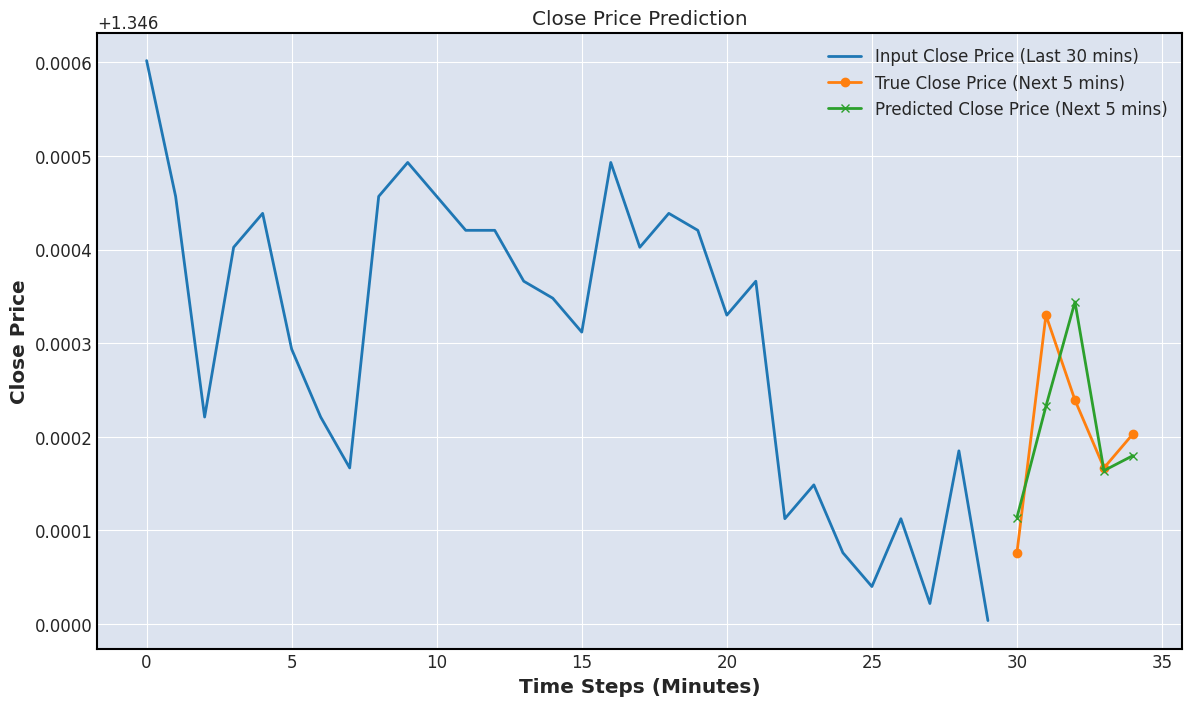

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


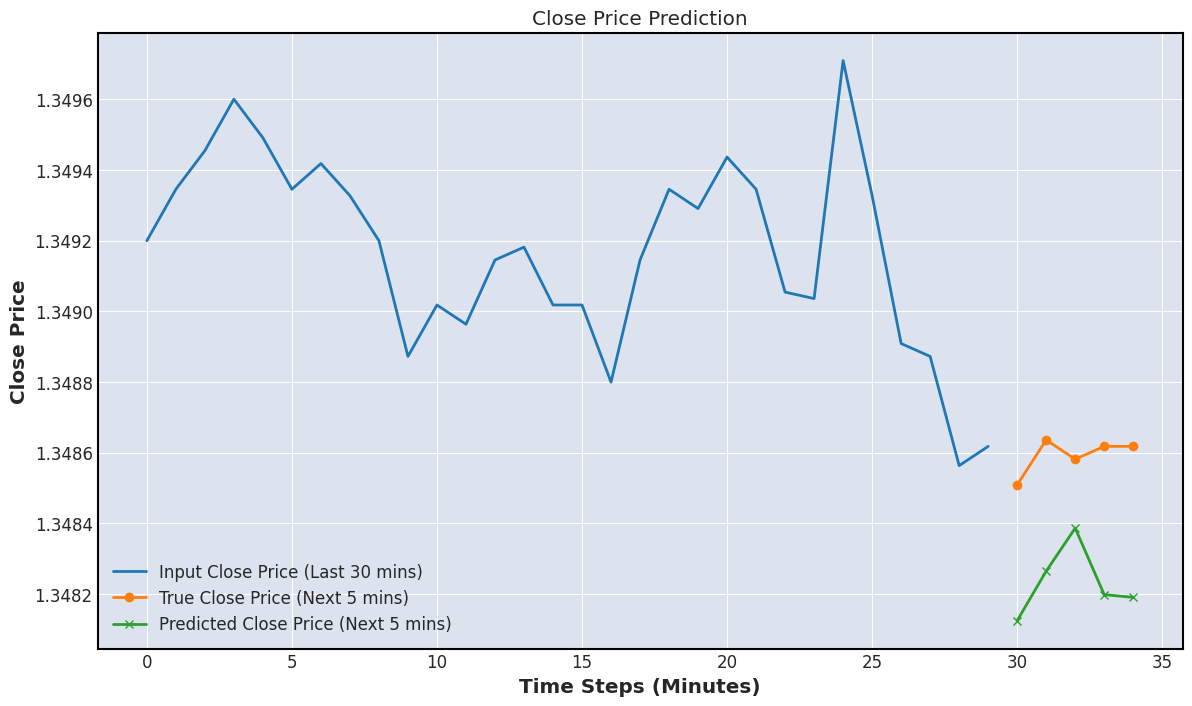

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


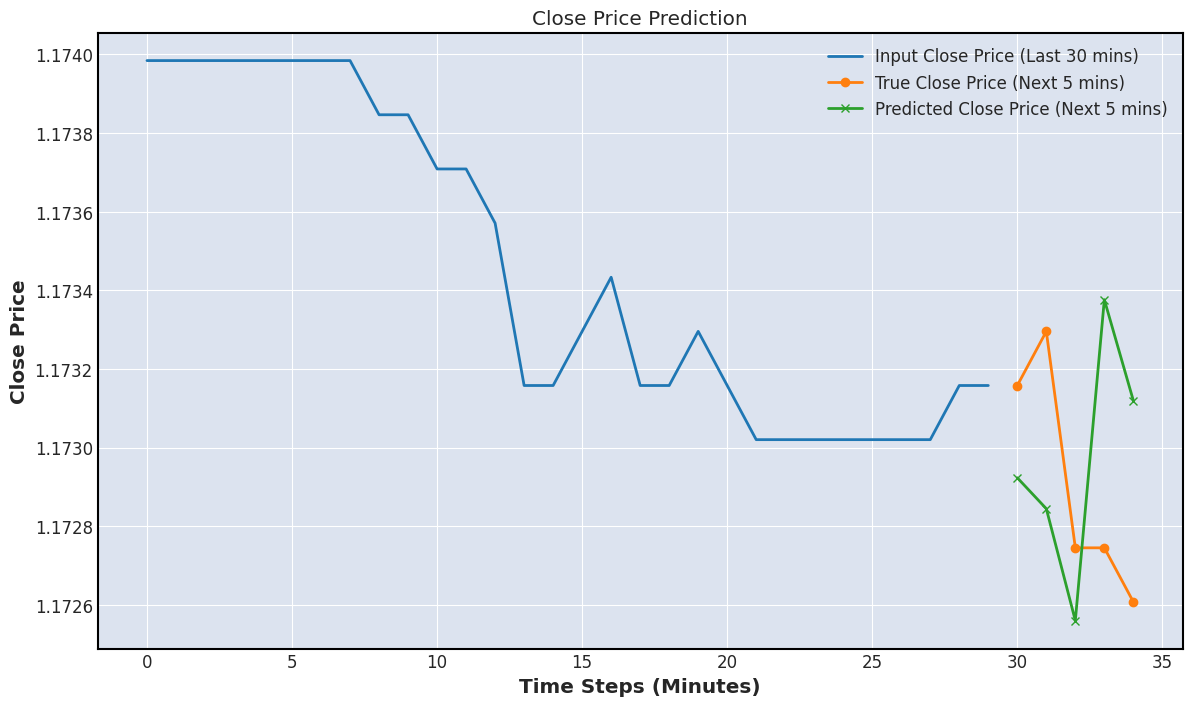

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


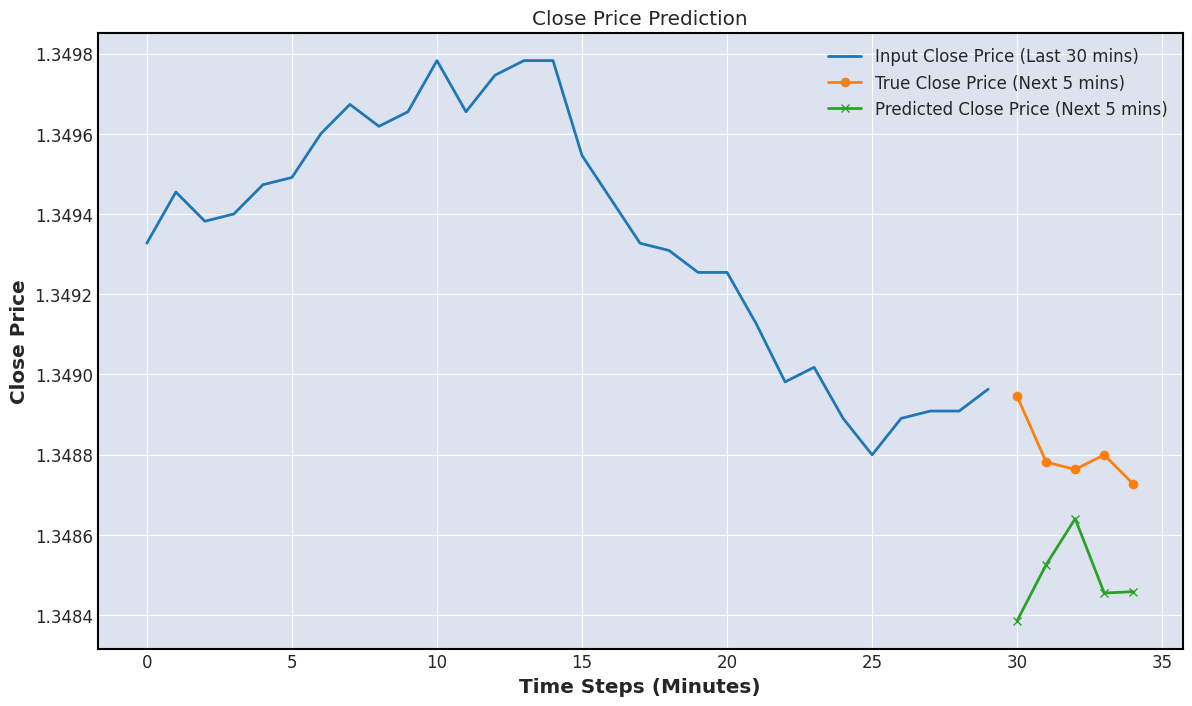

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


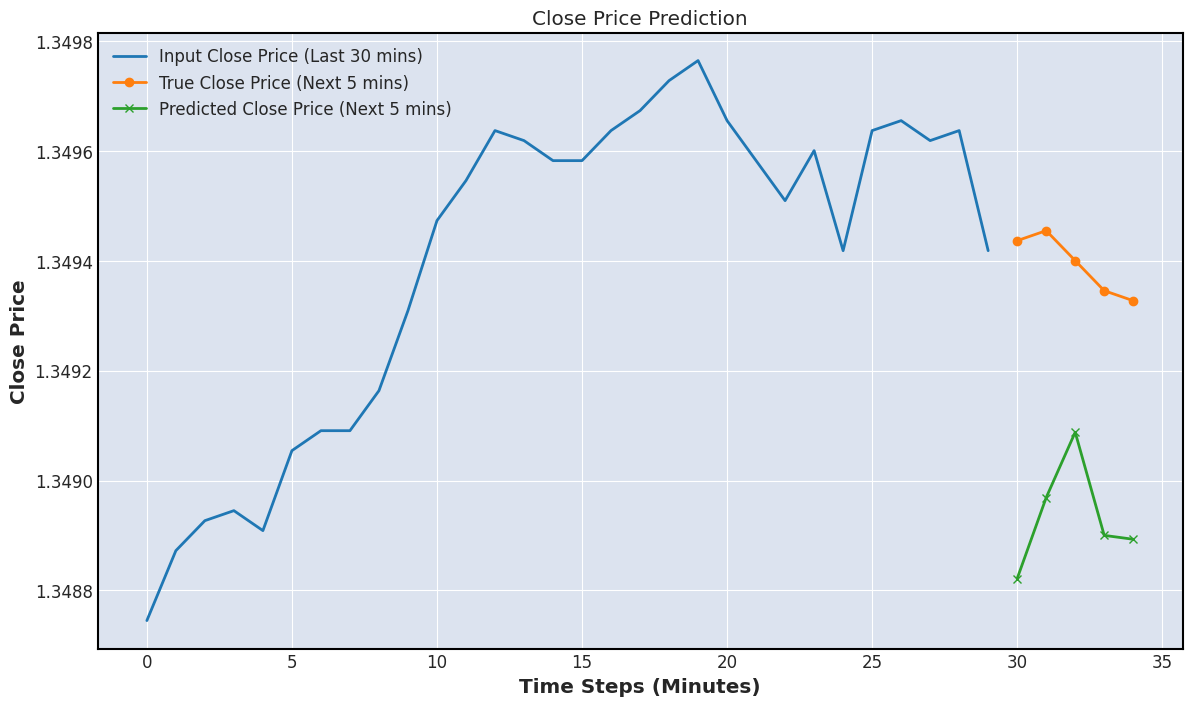

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


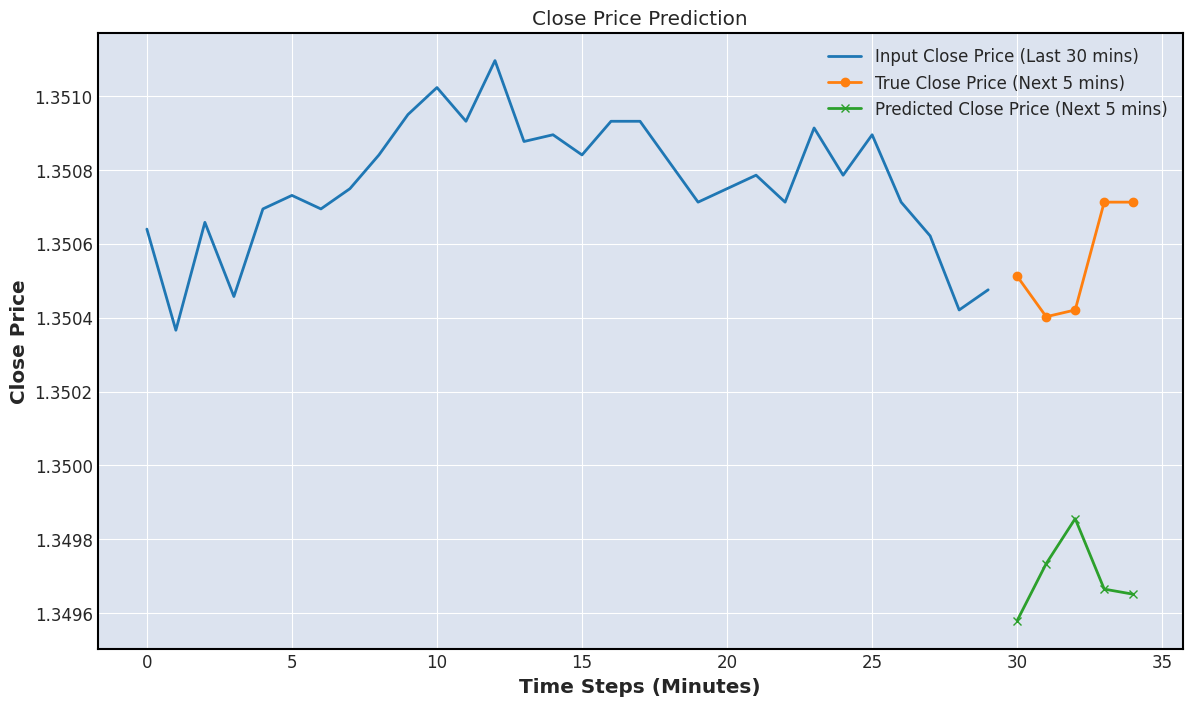

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


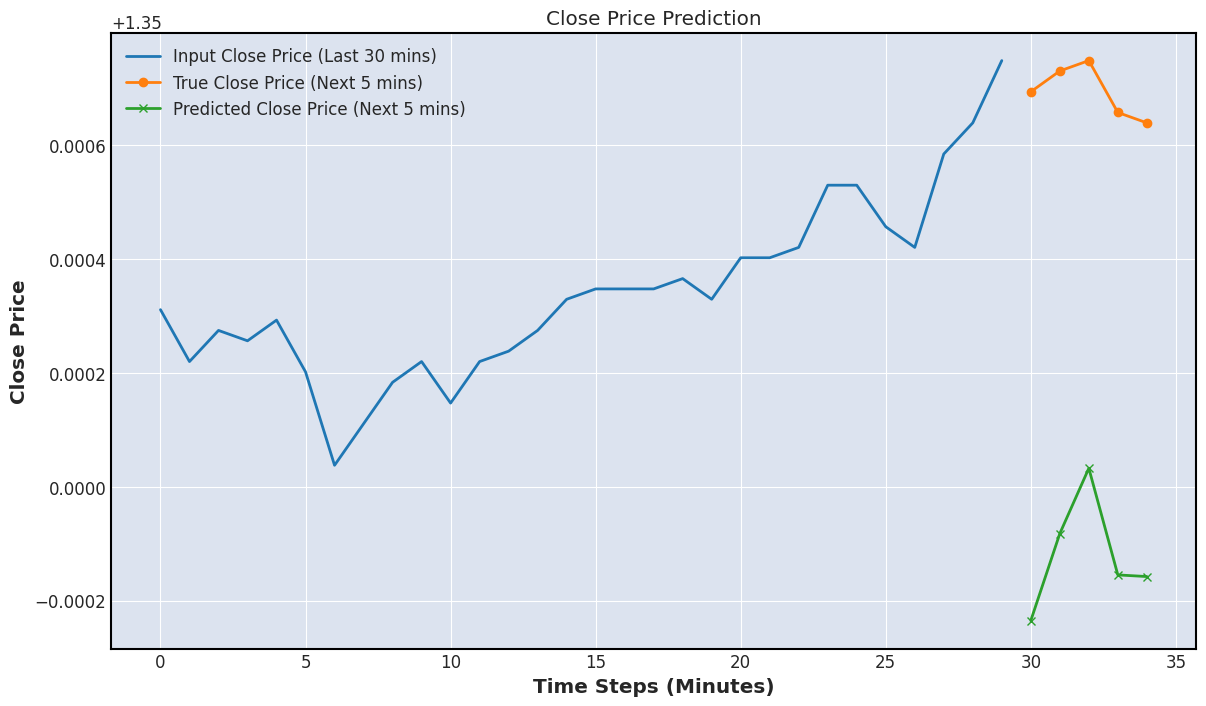

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


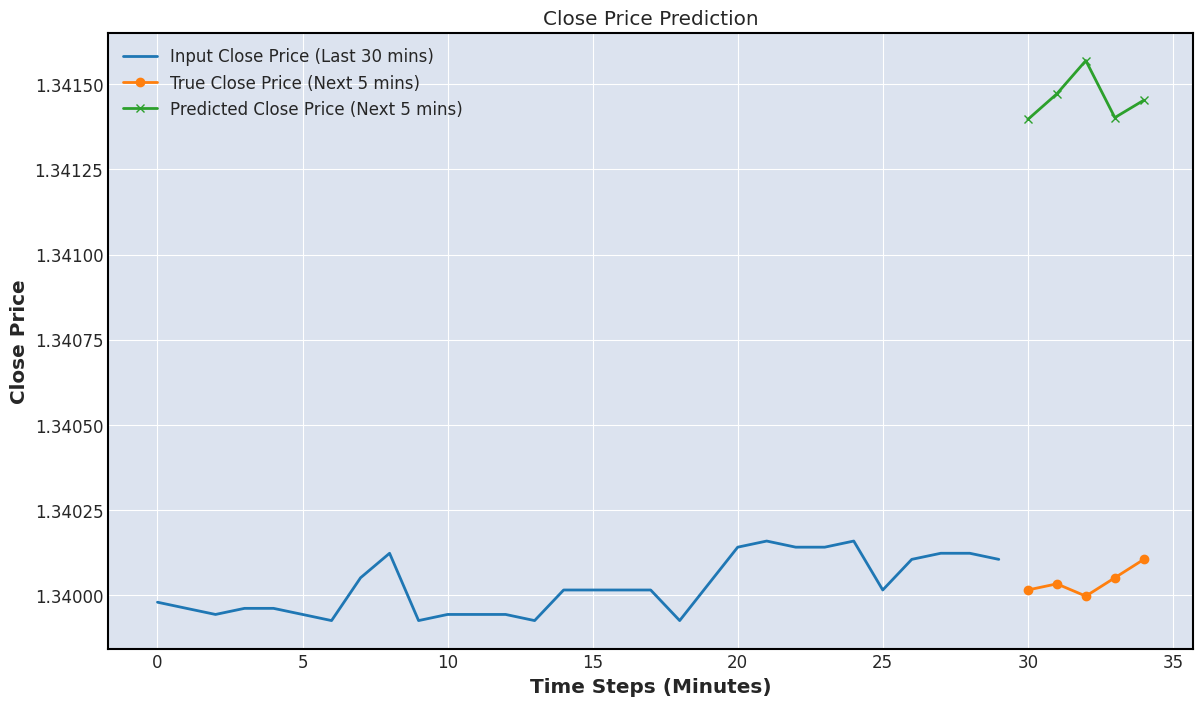

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


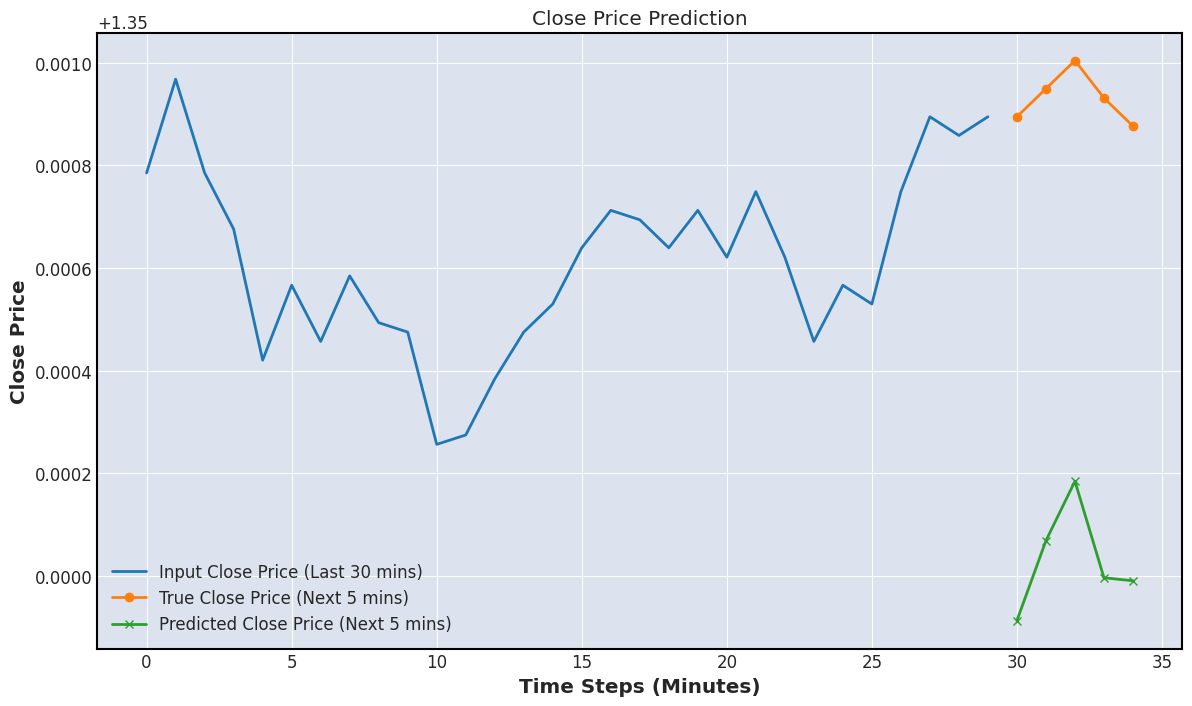

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


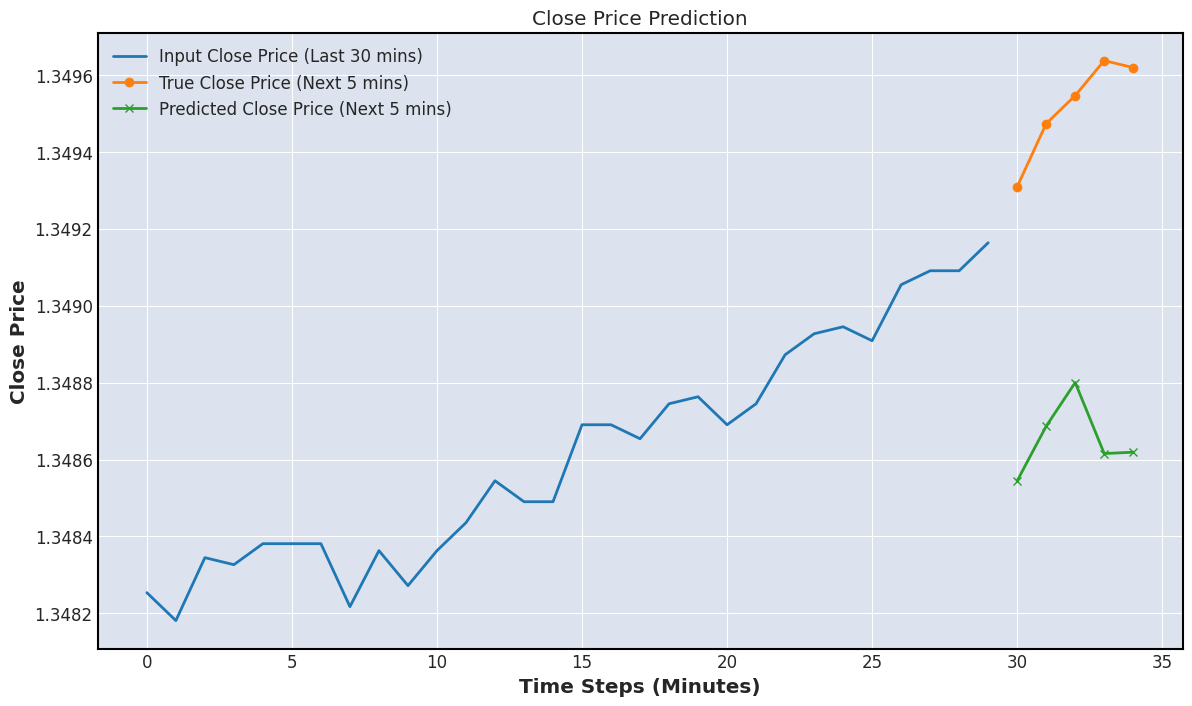

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


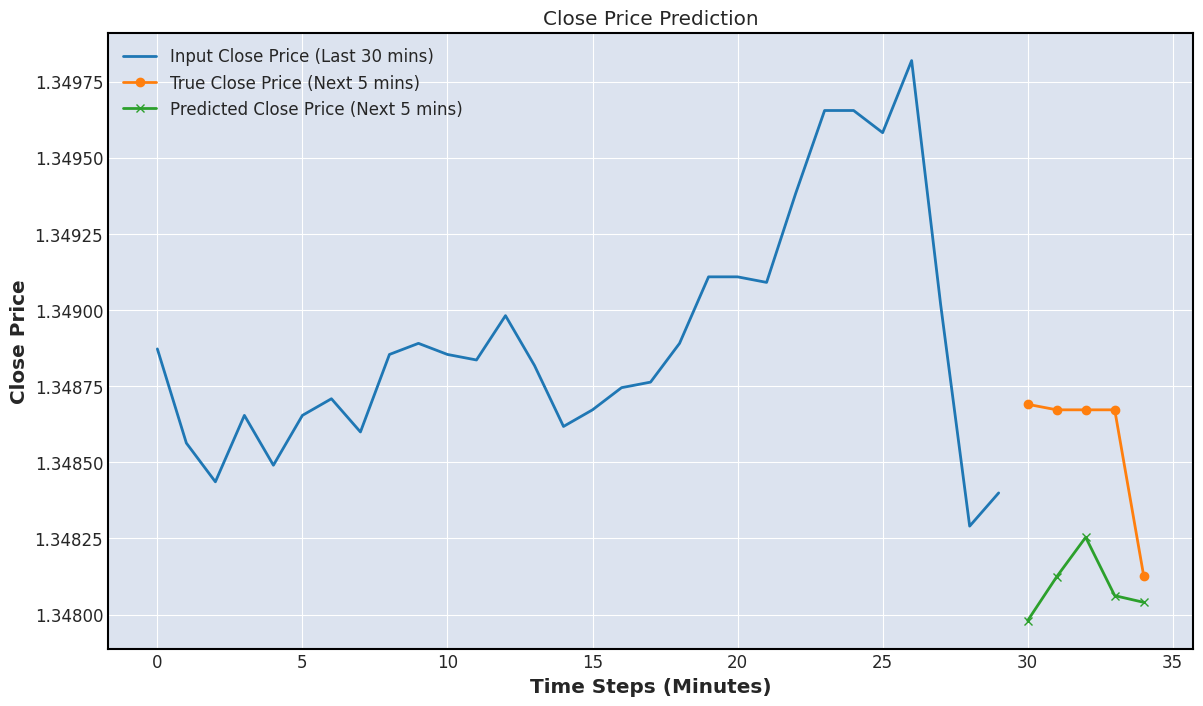

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


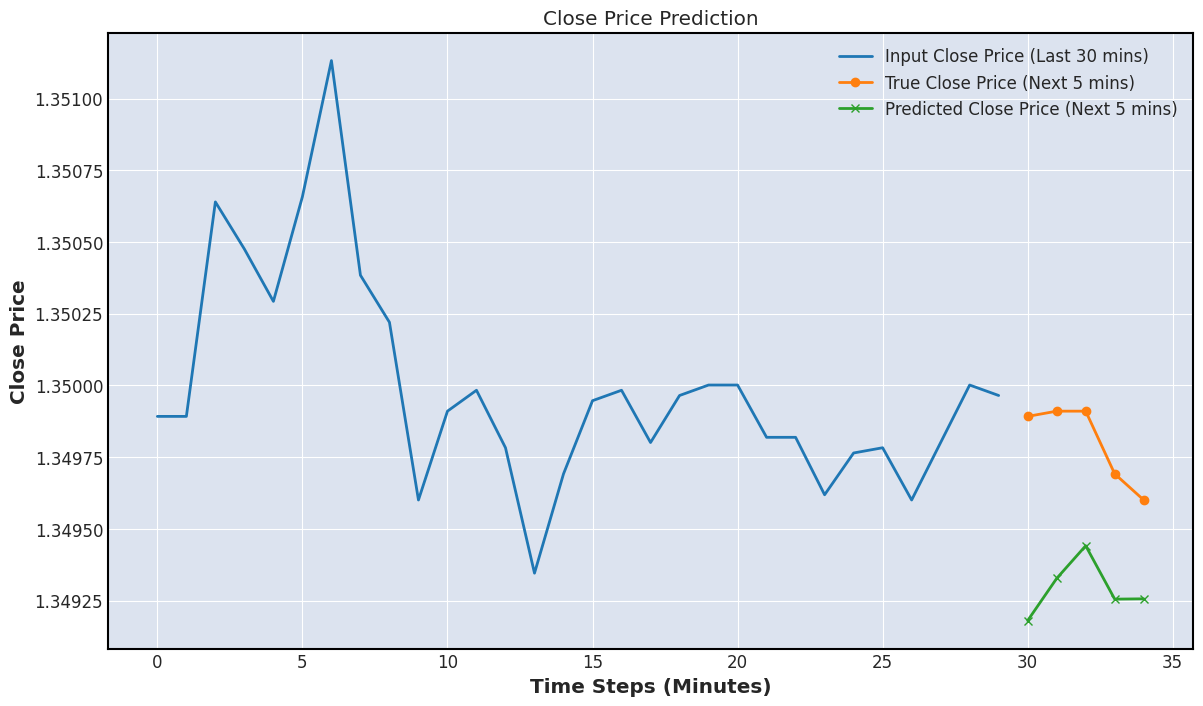

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


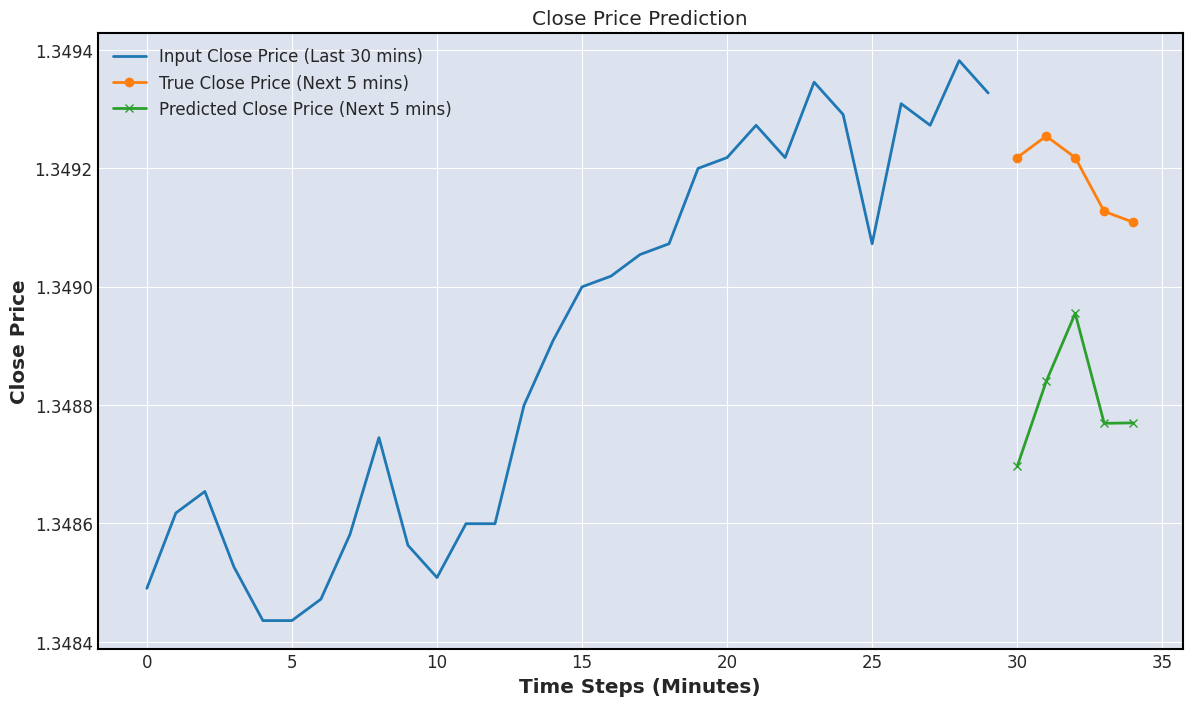

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


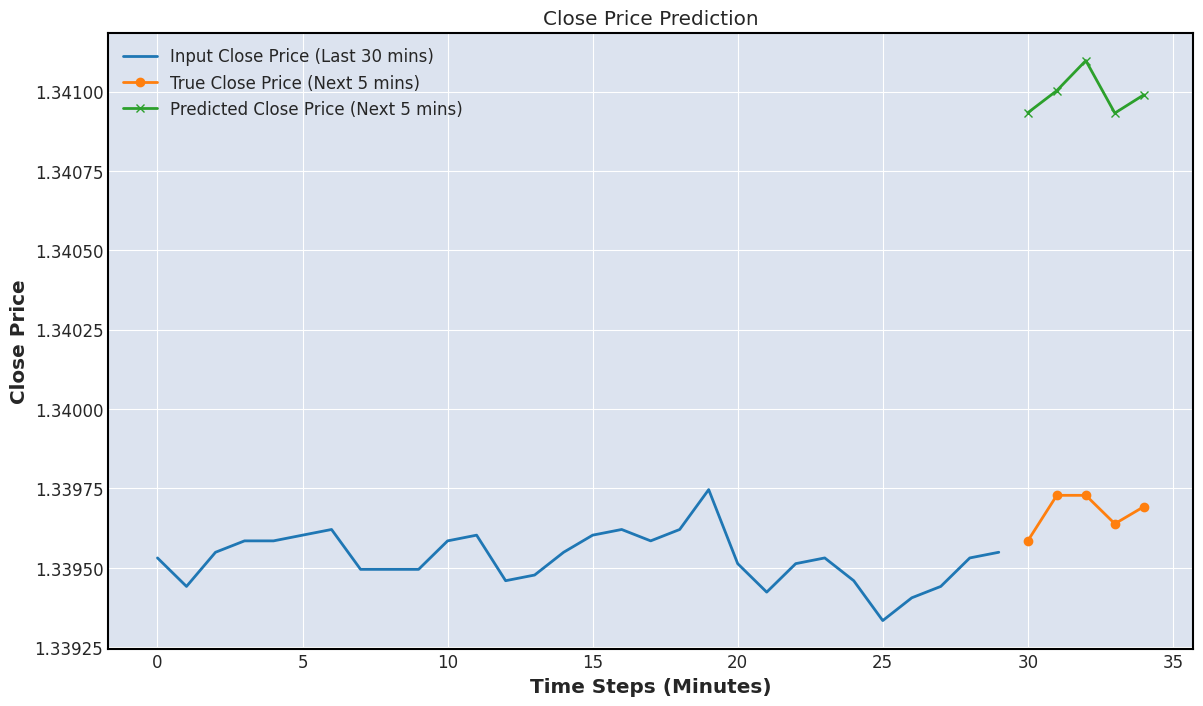

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


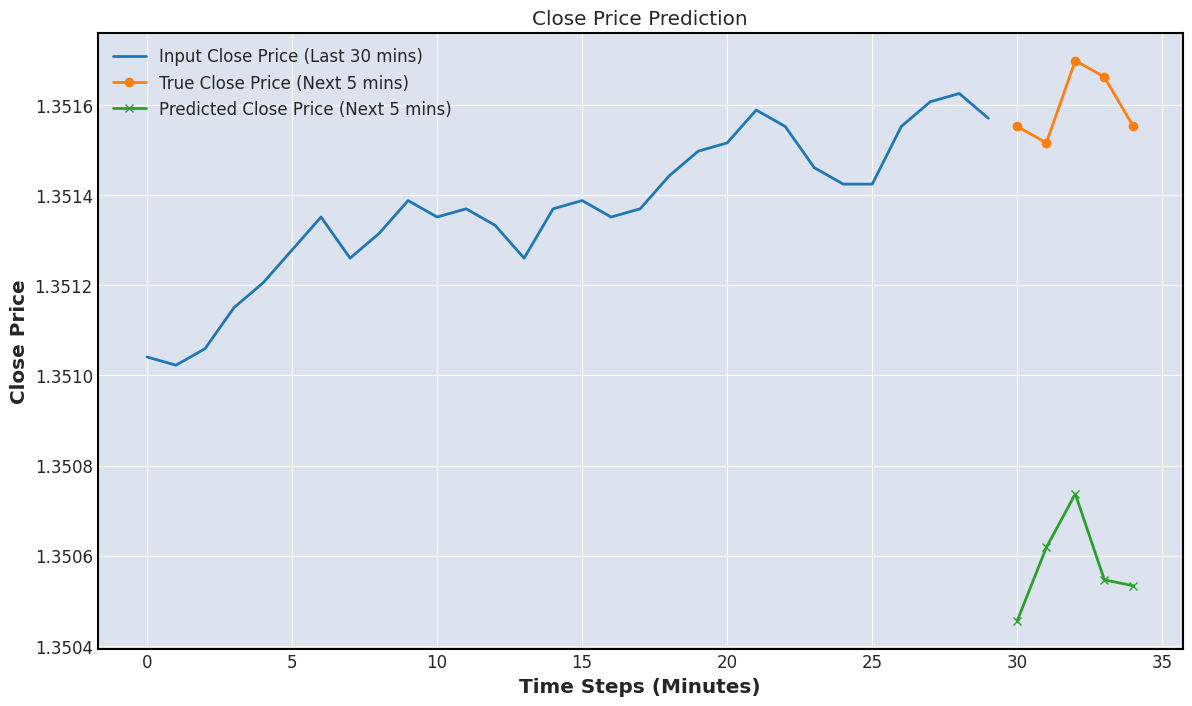

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


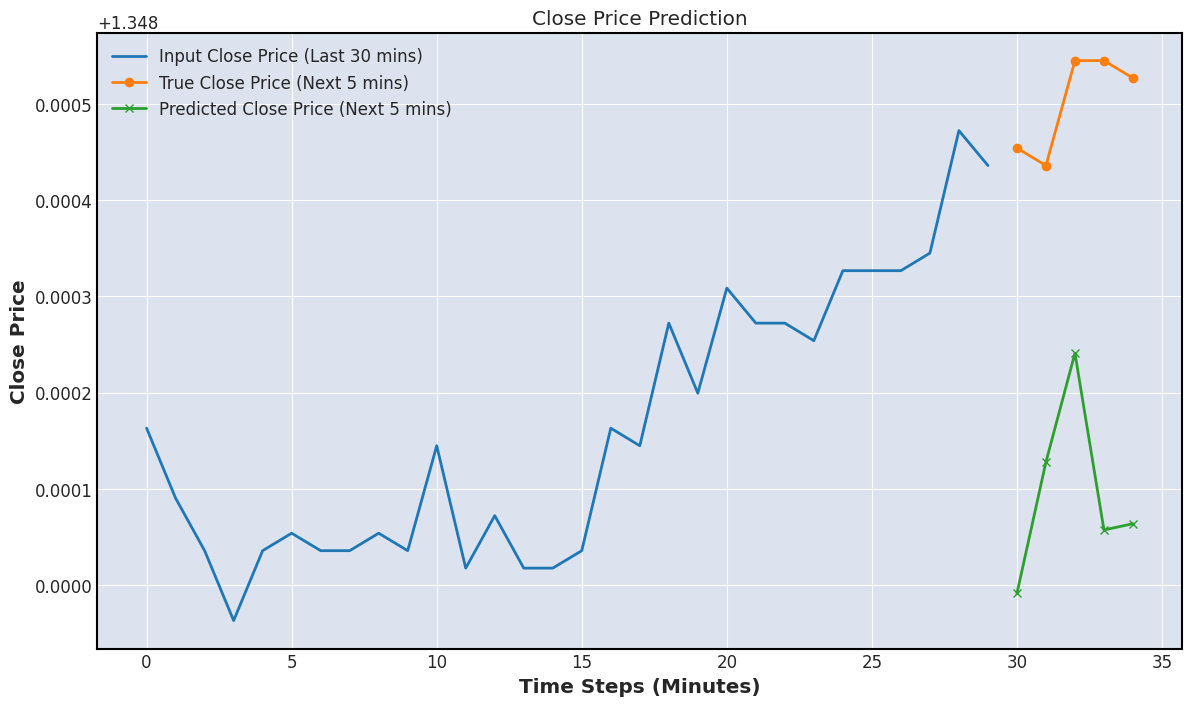

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


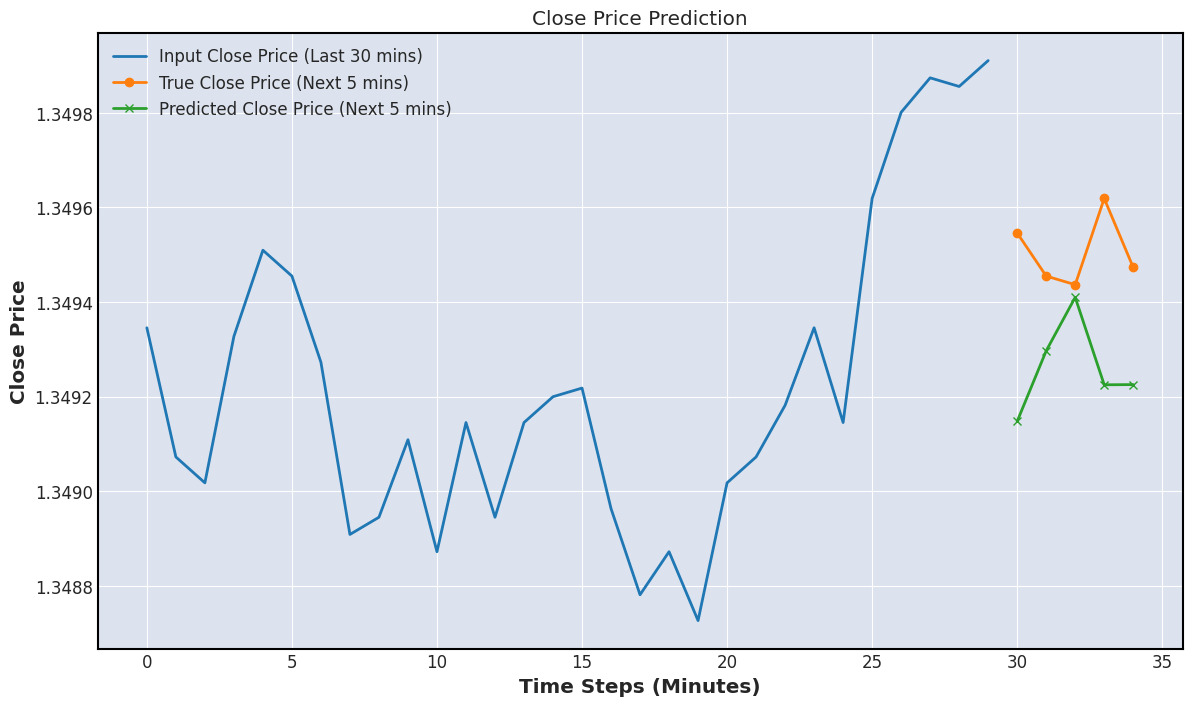

2025-12-31 12:53:56.274989: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# plot X sequence and predicted vs actual y for the first sequence from test set. Close is the last column in X

def inverse_transform_close(scaled_values):
    """Inverse transform Close prices from scaled values."""
    # Create dummy array with same shape as scaler expects (4 features)
    dummy = np.zeros((len(scaled_values), len(feature_cols)))
    dummy[:, CLOSE_COL_IDX] = scaled_values
    return scaler.inverse_transform(dummy)[:, CLOSE_COL_IDX]

i = 1
for X_batch, y_batch in test.take(20):
    X_sample = X_batch[0].numpy()
    y_true_scaled = y_batch[0].numpy()
    y_pred_scaled = model.predict(X_batch)[0]

    # Inverse transform for plotting in original scale
    X_close_original = inverse_transform_close(X_sample[:, -1])
    y_true_original = inverse_transform_close(y_true_scaled)
    y_pred_original = inverse_transform_close(y_pred_scaled)

    plt.figure(figsize=(14, 8))
    plt.plot(range(SEQUENCE_LENGTH), X_close_original, label='Input Close Price (Last 30 mins)')
    plt.plot(range(SEQUENCE_LENGTH, SEQUENCE_LENGTH + FORECAST_LENGTH), y_true_original, label='True Close Price (Next 5 mins)', marker='o')
    plt.plot(range(SEQUENCE_LENGTH, SEQUENCE_LENGTH + FORECAST_LENGTH), y_pred_original, label='Predicted Close Price (Next 5 mins)', marker='x')
    plt.xlabel('Time Steps (Minutes)')
    plt.ylabel('Close Price')
    plt.title('Close Price Prediction')
    plt.legend()
    # plt.savefig(os.path.join(EXPERIMENT_NAME, f"close_price_prediction_{i}.png"))
    plt.show()
    i += 1

In [ ]:
# Save a snapshot of this notebook to the experiment directory
import shutil
from datetime import datetime

notebook_path = "main.ipynb"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
snapshot_name = f"main_snapshot_{timestamp}.ipynb"
snapshot_path = os.path.join(EXPERIMENT_NAME, snapshot_name)

shutil.copy(notebook_path, snapshot_path)
print(f"Notebook snapshot saved to: {snapshot_path}")

Notebook snapshot saved to: usdgbp_forecast_004/main_snapshot_20251231_123500.ipynb
